In [1]:
# === Cell 1: 导入库与全局设置 ===
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# 1. 数据部分

In [3]:
# === Cell 2: 读取行情、计算收益 & 行业映射 ===
# 1) 市值 & 交易日 & 月末列表
mcap       = pd.read_csv('market_cap.csv', index_col=0, parse_dates=False)

#  交易日
trade_days = mcap.index


# 2) 收盘价 → 月度收益
price      = pd.read_csv('s_dq_adjclose_v2.csv', index_col=0, parse_dates=False)
price_m    = price.loc[trade_days]
ret_m      = price_m.shift(-1) / price_m - 1

trade_days

Index([20100129, 20100226, 20100331, 20100430, 20100531, 20100630, 20100730,
       20100831, 20100930, 20101029,
       ...
       20230331, 20230428, 20230531, 20230630, 20230731, 20230831, 20230928,
       20231031, 20231130, 20231229],
      dtype='int64', length=168)

In [5]:
# 3) 行业映射（基码→一级行业）
indus_df_raw       = pd.read_excel('行业分类表中信.xlsx')
indus_df_raw

,证券代码,证券简称,所属中信行业名称\n[交易日期] 最新收盘日\n[行业级别] 一级行业,所属中信行业代码\n[交易日期] 最新收盘日\n[行业级别] 一级行业,所属中信行业名称\n[交易日期] 最新收盘日\n[行业级别] 二级行业,所属中信行业代码\n[交易日期] 最新收盘日\n[行业级别] 二级行业
0,000003.SZ,PT金田A(退市),NaN,NaN,NaN,NaN
1,000013.SZ,*ST石化A(退市),NaN,NaN,NaN,NaN
2,000015.SZ,PT中浩A(退市),NaN,NaN,NaN,NaN
3,000018.SZ,神城A退(退市),建筑,b107000000000000,建筑装修Ⅱ,b107020000000000
4,000024.SZ,招商地产(退市),房地产,b10n000000000000,房地产开发和运营,b10n010000000000
...,...,...,...,...,...,...
5602,873693.BJ,阿为特,NaN,NaN,NaN,NaN
5603,873703.BJ,广厦环能,NaN,NaN,NaN,NaN
5604,873726.BJ,卓兆点胶,NaN,NaN,NaN,NaN
5605,873806.BJ,N云星宇,NaN,NaN,NaN,NaN


In [4]:
indus_df = indus_df_raw.set_index("证券代码")
indus_df.columns = ['证券简称', '一级行业', 'code1', '二级行业', 'code2']
ticker_industry_mapping = indus_df['一级行业'].to_dict()
# ticker_industry_mapping_rev = {v:k for k, v in ticker_industry_mapping.items()}
ticker_industry_mapping_rev = {}
for key, v in ticker_industry_mapping.items():
    if str(v) == 'nan':
        continue
    try:
        ticker_industry_mapping_rev[v].append(key)
    except:
        ticker_industry_mapping_rev[v] = [key]

indus_count = {name: len(ticker_industry_mapping_rev[name]) for name in ticker_industry_mapping_rev}
print("行业数量：", len(indus_count))
print("行业覆盖股票数量：", sum(indus_count.values()))  
print("行业覆盖股票数量占比：", sum(indus_count.values()) / len(indus_df))

indus_count

行业数量： 30
行业覆盖股票数量： 5522
行业覆盖股票数量占比： 0.9848403780988051


{'建筑': 171,
 '房地产': 127,
 '消费者服务': 62,
 '综合': 43,
 '医药': 506,
 '石油石化': 59,
 '家电': 89,
 '建材': 93,
 '钢铁': 59,
 '汽车': 250,
 '非银行金融': 76,
 '基础化工': 511,
 '电力设备及新能源': 321,
 '商贸零售': 119,
 '交通运输': 131,
 '电力及公用事业': 237,
 '计算机': 362,
 '综合金融': 17,
 '传媒': 159,
 '国防军工': 122,
 '有色金属': 136,
 '机械': 665,
 '煤炭': 37,
 '农林牧渔': 110,
 '通信': 133,
 '纺织服装': 106,
 '电子': 478,
 '轻工制造': 169,
 '食品饮料': 132,
 '银行': 42}

In [5]:
pat = pd.read_excel('PT_LCDOMFORAPPLY.xlsx', header=1)
pat = pat.iloc[1:]
pat

/Users/jason/anaconda3/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,证券代码,统计截止日期,报表类型,地区,申请类型编码,申请类型,专利,发明专利,实用新型,外观设计
1,000001,2021-12-31,1,1,S5205,截止报告期末累计已被受理,946,NaN,NaN,NaN
2,000001,2021-12-31,1,1,S5206,截止报告期末累计已授权,59,NaN,NaN,NaN
3,000001,2023-12-31,2,1,S5203,已授权,400,NaN,NaN,NaN
4,000001,2024-12-31,2,1,S5203,已授权,400,NaN,NaN,NaN
5,000002,2019-12-31,1,1,S5202,已获得,13,3,10,0
...,...,...,...,...,...,...,...,...,...,...
60564,920819,2020-12-31,1,1,S5206,截止报告期末累计已授权,241,NaN,NaN,NaN
60565,920819,2021-12-31,1,1,S5204,截至报告期末累计获得,285,143,NaN,NaN
60566,920819,2021-12-31,1,1,S5206,截止报告期末累计已授权,285,NaN,NaN,NaN
60567,920819,2022-12-31,1,1,S5204,截至报告期末累计获得,350,177,NaN,NaN


In [6]:
def get_ticker(code: str) -> str:
    """
    根据 A 股证券代码生成完整 Ticker（带交易所后缀），如 '000001.SZ'
    """
    if code.startswith(("6", "9")):  # 上交所：以 6、9 开头（主板、科创板等）
        return f"{code}.SH"
    elif code.startswith(("0", "3")):  # 深交所：0 是主板、3 是创业板
        return f"{code}.SZ"
    elif code.startswith(("2")):  # B 股（200）
        return f"{code}.SZ"
    elif code.startswith(("430")):  # 北交所：430 是北交所
        return f"{code}.BJ"
    elif code.startswith(("8")):  # 新三板：8 是新三板 后转北交所
        return f"{code}.BJ"
    else:
        raise ValueError(f"未知的证券代码开头: {code}")

pat['证券代码'] = pat['证券代码'].map(get_ticker)
pat = pat.set_index(['证券代码', '统计截止日期'])
pat

报表类型 地区 申请类型编码          申请类型   专利 发明专利 实用新型 外观设计
证券代码      统计截止日期                                                     
000001.SZ 2021-12-31    1  1  S5205  截止报告期末累计已被受理  946  NaN  NaN  NaN
          2021-12-31    1  1  S5206   截止报告期末累计已授权   59  NaN  NaN  NaN
          2023-12-31    2  1  S5203           已授权  400  NaN  NaN  NaN
          2024-12-31    2  1  S5203           已授权  400  NaN  NaN  NaN
000002.SZ 2019-12-31    1  1  S5202           已获得   13    3   10    0
...                   ... ..    ...           ...  ...  ...  ...  ...
920819.SH 2020-12-31    1  1  S5206   截止报告期末累计已授权  241  NaN  NaN  NaN
          2021-12-31    1  1  S5204    截至报告期末累计获得  285  143  NaN  NaN
          2021-12-31    1  1  S5206   截止报告期末累计已授权  285  NaN  NaN  NaN
          2022-12-31    1  1  S5204    截至报告期末累计获得  350  177  NaN  NaN
          2023-12-31    1  1  S5204    截至报告期末累计获得  383  196  NaN  NaN

[60568 rows x 8 columns]

In [7]:
set(pat['申请类型'])

{'已授权', '已申请', '已获得', '截止报告期末累计已授权', '截止报告期末累计已被受理', '截至报告期末累计获得'}

In [8]:
pat.groupby('申请类型')['发明专利'].count().sort_values(ascending=False)

申请类型
截至报告期末累计获得      13235
已申请              8109
已授权              7882
已获得              6230
截止报告期末累计已授权      4753
截止报告期末累计已被受理     3931
Name: 发明专利, dtype: int64

In [ ]:
pat = pat.loc[pat['申请类型'] == "截至报告期末累计获得"]
pat = pat.loc[pat['地区'] == 1] # 国内的专利
pat = pat.loc[pat['报表类型'] == 1] # 合并报表而不是单单母公司报表，报表=2，因为母公司可能会提供资金人力给子公司研究专利，成果应当合并来看

In [ ]:
pat['发明专利'].unstack().T  # 以时间为纵轴，以股票为横轴

证券代码,000002.SZ,000004.SZ,000008.SZ,000012.SZ,000019.SZ,000021.SZ,000022.SZ,000026.SZ,000027.SZ,000030.SZ,...,920088.SH,920099.SH,920108.SH,920111.SH,920167.SH,920445.SH,920489.SH,920682.SH,920799.SH,920819.SH
统计截止日期,,,,,,,,,,,,,,,,,,,,,
2007-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2009-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-12-31,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-12-31,NaN,NaN,NaN,44,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-12-31,NaN,NaN,NaN,NaN,28,19,NaN,15,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
factor_cumsum = pat['发明专利'].unstack().T.ffill()
factor_1Y = (factor_cumsum - factor_cumsum.shift(1)).fillna(0)
factor_1Y

证券代码,000002.SZ,000004.SZ,000008.SZ,000012.SZ,000019.SZ,000021.SZ,000022.SZ,000026.SZ,000027.SZ,000030.SZ,...,920088.SH,920099.SH,920108.SH,920111.SH,920167.SH,920445.SH,920489.SH,920682.SH,920799.SH,920819.SH
统计截止日期,,,,,,,,,,,,,,,,,,,,,
2007-12-31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2008-12-31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2009-12-31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2010-12-31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-12-31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2012-12-31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2013-12-31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2014-12-31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2015-12-31,0.0,0.0,0.0,0.0,0.0,15.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [12]:
# 转化为月度数据
factor_1Y.index = [int(i.replace("-", "")) for i in factor_1Y.index]

union = list(trade_days)
union.extend(list(factor_1Y.index))
union = list(set(union))
union.sort()

factor_1Y_monthly = factor_1Y.reindex(union).ffill().loc[trade_days]
factor_1Y_monthly

证券代码,000002.SZ,000004.SZ,000008.SZ,000012.SZ,000019.SZ,000021.SZ,000022.SZ,000026.SZ,000027.SZ,000030.SZ,...,920088.SH,920099.SH,920108.SH,920111.SH,920167.SH,920445.SH,920489.SH,920682.SH,920799.SH,920819.SH
20100129,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20100226,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20100331,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20100430,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20100531,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20230831,99.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,9.0,9.0,0.0,6.0,34.0
20230928,99.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,9.0,9.0,0.0,6.0,34.0
20231031,99.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,9.0,9.0,0.0,6.0,34.0
20231130,99.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,9.0,9.0,0.0,6.0,34.0


In [13]:
factor_1Y_monthly.iloc[-1].sort_values(ascending=False)

证券代码
600100.SH    5814.0
601668.SH    4713.0
002475.SZ    4525.0
002415.SZ    1544.0
601618.SH    1500.0
              ...  
600535.SH     -64.0
002376.SZ     -64.0
688197.SH     -69.0
603978.SH    -112.0
002402.SZ    -131.0
Name: 20231229, Length: 3786, dtype: float64

# 2. Universe 的构建和筛选

In [14]:
from typing import Tuple, Dict, Optional

def calc_ic(factor: pd.DataFrame, monthly_ret: pd.DataFrame, cal_factor_return = False, use_spearman=True) -> Tuple[Dict, pd.Series] :
    ic = {}
    fr = {}
    ts = factor.index.intersection(monthly_ret.index)
    ts = ts[:-1]  # 排除最后一天的因子

    for day in ts:
        f_i = factor.loc[day].dropna()
        r_i = monthly_ret.loc[day].dropna()
        common_assets = f_i.index.intersection(r_i.index)

        if len(common_assets) == 0:
            # print("factor value all nan in", day)
            # ic[day] = np.nan
            fr[day] = np.nan
            continue

        if f_i.std() == 0:
            # print("same factor value in", day)
            ic[day] = np.nan
            fr[day] = np.nan
            continue

        f_i = f_i.loc[common_assets]
        r_i = r_i.loc[common_assets]

        # 计算 IC（信息系数，即因子值和未来收益的 Spearman 相关系数）
        if use_spearman:
            ic[day], _ = spearmanr(f_i, r_i)
        else:
            ic[day] = np.corrcoef(f_i, r_i)[0, 1]

        # 横截面回归，r_i = alpha + beta * f_i + epsilon，beta 就是因子收益
        # 做这个回归需要对因子进行归一化, 只有这样得出的回归系数才有真实的意义
        # 因为这个操作比较耗时，初筛时可以选择不做，得出的结论和 IC 差不多
        if cal_factor_return:
            f_i = (f_i - f_i.mean()) / f_i.std()
            X = sm.add_constant(f_i)  # 添加截距项
            model = sm.OLS(r_i, X)
            results = model.fit()
            fr[day] = results.params[f_i.name] if f_i.name in results.params else results.params[1]
        else:
            fr[day] = 0

    ic_series = pd.Series(ic)
    fr_series = pd.Series(fr)
    n = fr_series.count()
    mean = fr_series.mean()
    std = fr_series.std(ddof=1)

    summary = {
        "IC": ic_series.mean(),
        "IC_positive": sum(ic_series > 0) / len(ic_series),
        "IR": ic_series.mean() / ic_series.std() if ic_series.std() != 0 else np.nan,
        "Factor Mean Return": fr_series.mean(),
        "Factor Return tstat":  mean / (std / np.sqrt(n)) if std > 0 else np.nan
    }

    return summary, fr_series

def convert_index_to_datetime(df: pd.DataFrame|pd.Series):
    index = df.index
    # 判断是否是形如 20250101 的整数或字符串格式
    if all(isinstance(i, (int, str)) and len(str(i)) == 8 for i in index):
        try:
            df.index = pd.to_datetime(index, format="%Y%m%d")
        except Exception as e:
            print("转换失败：", e)
    else:
        print("索引不是 yyyymmdd 格式，未做转换")
    return df

# 因子生成函数
def gen_factors(factor_3Y, universe: Optional[pd.DataFrame]=None):
    factors = {}
    # 原始市值
    factors['fmsq_3Y'] = factor_3Y

    if not universe is None:
        for f, v in factors.items():
            v = v.reindex(columns=universe.columns).fillna(0)
            v = v.loc[universe.index]
            factors[f] = v * universe
    return factors

In [15]:
# 转换为 DataFrame
df = pd.Series(ticker_industry_mapping, name="industry").to_frame()

# 创建 dummy 变量
dummy_df = pd.get_dummies(df['industry'])
dummy_df

,交通运输,传媒,农林牧渔,医药,商贸零售,国防军工,基础化工,家电,建材,建筑,...,纺织服装,综合,综合金融,计算机,轻工制造,通信,钢铁,银行,非银行金融,食品饮料
000003.SZ,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
000013.SZ,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
000015.SZ,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
000018.SZ,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
000024.SZ,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
873693.BJ,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
873703.BJ,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
873726.BJ,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
873806.BJ,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [16]:
select_industries = [
    '石油石化',
    '基础化工',
    '机械' ,
    '电子' ,
    '汽车' ,
    '有色金属' ,
    '通信' ,
    '医药' ,
    '建材' ,
    '钢铁',
    '轻工制造',
    '计算机' ,
    '电力设备及新能源' ,
    '家电' ,
    '建筑' ,
    '国防军工'
]

dummy_df = dummy_df[select_industries]
dummy_df = dummy_df.map(lambda x: 1 if x else 0)
dummy_df = dummy_df.loc[dummy_df.sum(1) > 0]

# new universe
new_universe = dummy_df.index

# 检查一下数量
print(dummy_df.sum())
dummy_df

石油石化         59
基础化工        511
机械          665
电子          478
汽车          250
有色金属        136
通信          133
医药          506
建材           93
钢铁           59
轻工制造        169
计算机         362
电力设备及新能源    321
家电           89
建筑          171
国防军工        122
dtype: int64


,石油石化,基础化工,机械,电子,汽车,有色金属,通信,医药,建材,钢铁,轻工制造,计算机,电力设备及新能源,家电,建筑,国防军工
000018.SZ,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
000150.SZ,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
000406.SZ,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
000418.SZ,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
000511.SZ,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
873305.BJ,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
873339.BJ,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
873576.BJ,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
873593.BJ,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0


# 3. 因子测试

In [17]:
def rowwise_residuals(df1: pd.DataFrame, df2: pd.DataFrame, industry_dummy: pd.DataFrame) -> pd.DataFrame:
    """
    industry_dummy: shape = (n_assets, n_industries)
    df1, df2: shape = (n_samples, n_assets)
    
    对 df1 的每一行 y，用 df2 的对应行 + 行业哑变量作为 X 做 OLS，输出残差
    """
    assert df1.shape == df2.shape, "df1 和 df2 的 shape 必须一致"
    assert df1.shape[1] == industry_dummy.shape[0], "df1 的列数（资产数）必须与 industry_dummy 的行数一致"

    residuals = []
    index = df1.index
    columns = df1.columns

    # 预处理行业哑变量（资产数 × 行业数）
    industry_matrix = industry_dummy.values  # shape = (n_assets, n_industries)

    for i in range(len(df1)):
        y = df1.iloc[i].values           # shape = (n_assets,)
        x_factor = df2.iloc[i].values    # shape = (n_assets,)

        # 处理缺失和异常
        if pd.isna(y).all() or pd.isna(x_factor).all() or np.std(x_factor) == 0:
            residuals.append([np.nan] * len(y))
            continue

        # 去均值 + 缺失填充
        y_centered = y - np.nanmean(y)
        y_clean = np.nan_to_num(y_centered, nan=0.0)

        x_centered = x_factor - np.nanmean(x_factor)
        x_clean = np.nan_to_num(x_centered, nan=0.0)

        # 拼接：列拼接为 design matrix: [x_clean | industry_dummies]
        X_full = np.column_stack([x_clean, industry_matrix])  # shape: (n_assets, 1 + n_industries)

        # 加入截距项
        X_full = sm.add_constant(X_full)

        # 回归
        model = sm.OLS(y_clean, X_full)
        results = model.fit()

        eps = results.resid
        residuals.append(eps)

    res_df = pd.DataFrame(residuals, index=index, columns=columns)
    return res_df


# 因子生成函数
def gen_factors(market_cap, factor_1Y_monthly, dummy_df, universe: Optional[pd.DataFrame]=None):
    factors = {}
    new_universe = dummy_df.index
    # 原始市值
    f = factor_1Y_monthly.reindex(columns=new_universe).fillna(0)
    log_market_cap = np.log(market_cap.reindex(columns=new_universe))
    factors['fmsq_1Y'] = rowwise_residuals(f, log_market_cap, dummy_df)
    print(factors['fmsq_1Y'].iloc[-1].sort_values())

    if not universe is None:
        for f, v in factors.items():
            v = v.loc[universe.index]
            factors[f] = v * universe
    return factors


my_factors = gen_factors(mcap, factor_1Y_monthly, dummy_df)

res_all = {}
factor_ret_all = {}
for factor_name, factor_value in my_factors.items():
    try:
        summary, fr_series = calc_ic(factor_value, ret_m, cal_factor_return=True, use_spearman=True)
        res_all[factor_name] = summary
        factor_ret_all[factor_name] = fr_series
    except:
        raise Exception(f"[{factor_name}] Error")
    
res_all = pd.DataFrame(res_all).T
res_all

002402.SZ    -164.712203
601390.SH    -112.485640
601857.SH    -110.493453
601800.SH    -109.602828
002594.SZ    -108.149703
                ...     
601618.SH    1405.319047
002415.SZ    1437.850297
002475.SZ    4424.983110
601668.SH    4592.451860
600100.SH    5764.076860
Name: 20231229, Length: 4124, dtype: float64


,Factor Mean Return,Factor Return tstat,IC,IC_positive,IR
fmsq_1Y,0.000802,3.272244,0.037613,0.628743,0.33431


<Axes: >

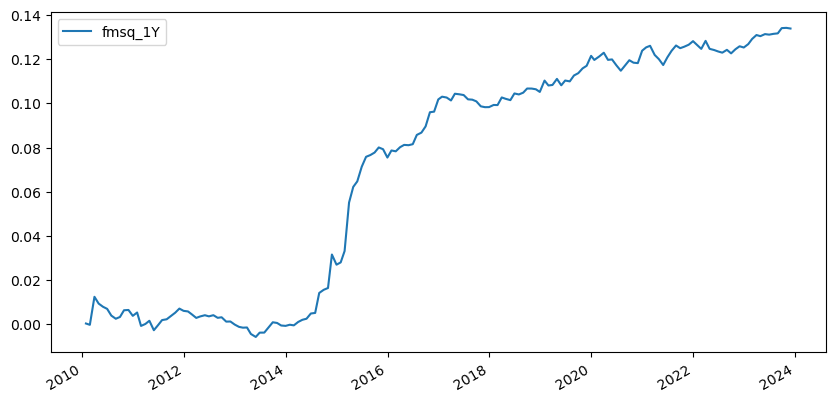

In [18]:
factor_ret_all = pd.DataFrame(factor_ret_all)
factor_ret_all = convert_index_to_datetime(factor_ret_all)
factor_ret_all.cumsum().plot(figsize=(10, 5))